# S&P 500 Options: Portfolio Construction

`12_backtest` weighted the straddles it sold equally: every symbol held on a decision date got
the same share of capital. That is a deliberate null - it uses the model only to decide *which*
symbols to trade, never *how much* of each. This notebook keeps the same symbols and varies the
weighting rule, so that any difference in the result is attributable to the allocator and to
nothing else.

The rules come in two kinds. One reads the prediction itself and puts more capital behind a
stronger score. The others ignore the prediction and read the covariance of the underlying
returns, sizing positions so that each contributes comparable risk rather than comparable
capital. Both kinds are common in practice and they fail in different ways, which is the point
of running them side by side.

The results extend the immutable candidate set that `18_strategy_analysis` selects from.

**Learning objectives**

- Freeze a set of finished backtests into a named candidate set whose membership cannot change
  afterwards, and read the selection rule off that set rather than off the registry.
- Advance a fixed number of distinct model configurations to the next stage, counting
  configurations rather than backtest rows so that one model cannot occupy the shortlist.
- Vary a single strategy field across an entire shortlist and keep every other field equal, so
  the comparison is paired.

**Book reference**: Chapter 17

**Prerequisites**: the complete baseline population published by `12_backtest`.

In [1]:
"""Execute the declared S&P 500 options allocation population."""

import plotly.express as px
import polars as pl

from case_studies.research import (
    CandidateSet,
    OfficialPopulation,
    Result,
    candidate_set_supersedes,
    supersedes_for_run,
)
from case_studies.sp500_options.research_workflow import (
    ALL_LABELS,
    open_study,
    paired_sharpe_on_common_support,
    preview_baseline_candidates,
    run_official_backtest_requests,
    strategy_request_frame,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_n_predictions,
)
from utils.style import COLORS, show_plotly_with_alt

CASE_STUDY = "sp500_options"
BASELINE_POPULATION = "sp500-options-baseline-validation-v1"
BASELINE_CANDIDATES = "sp500-options-baseline-candidates-v1"
STRATEGY_CANDIDATES = "sp500-options-strategy-candidates-v1"
ALLOCATION_POPULATION = "sp500-options-allocation-validation-v1"

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_LABELS: list[str] = []
PREVIEW_MAX_BASELINE_CONFIGS = 0
PREVIEW_ALLOCATORS: tuple[str, ...] = ("score_weighted",)
# The generation each named set retires. A set and a population are immutable under their
# name, so a re-run whose membership moved has to say which one it replaces; the refusal
# names the current hash, and empty is correct only for a name this registry has never held.
# Each of these is stale the moment the run it authorizes succeeds, because that run becomes
# the generation the next one has to name.
SUPERSEDES_BASELINE_CANDIDATES: str = "caa48f7d7108"
SUPERSEDES_ALLOCATION_POPULATION: str = "2120daa51778"
SUPERSEDES_STRATEGY_CANDIDATES: str = "2b2083f67223"

## Freeze what is being selected from

A candidate set is the list of results a selection is allowed to consider, written down and
hashed before the selection happens. A selection rule only has a definite answer once the set it
ranges over is fixed: the same rule applied to a registry that has since gained a row returns a
different result, and the result alone does not record which set produced it.

A preview run selects its baselines by label and freezes nothing, because a candidate set built
from reduced results would authorize a selection the reduced run cannot support. It selects by
label rather than by hash so that the declaration can be written down: a backtest hash is a
property of the run that produced it, so a preview named by hash can only be launched from the
machine that has just produced one.

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
baseline_candidates: CandidateSet | None
if EXECUTION_TIER == "canonical" and (PREVIEW_LABELS or PREVIEW_MAX_BASELINE_CONFIGS):
    raise ValueError("canonical execution cannot declare preview reductions")
if EXECUTION_TIER == "canonical":
    baseline_population = OfficialPopulation.one(study, name=BASELINE_POPULATION)
    baseline_hashes = baseline_population.require_complete()
    baseline_table = study.backtests.table().filter(pl.col("backtest_hash").is_in(baseline_hashes))
    if baseline_table.height != len(baseline_hashes):
        raise RuntimeError("the baseline backtest catalog is incomplete")
    baseline_candidates = study.backtests.freeze(
        baseline_table,
        name=BASELINE_CANDIDATES,
        supersedes=candidate_set_supersedes(
            study,
            name=BASELINE_CANDIDATES,
            declared=SUPERSEDES_BASELINE_CANDIDATES or None,
        ),
    )
elif EXECUTION_TIER == "preview":
    if not WORKSPACE or not PREVIEW_LABELS or PREVIEW_MAX_BASELINE_CONFIGS < 1:
        raise ValueError(
            "preview execution requires WORKSPACE, PREVIEW_LABELS and PREVIEW_MAX_BASELINE_CONFIGS"
        )
    unknown = sorted(set(PREVIEW_LABELS) - set(ALL_LABELS))
    if unknown:
        raise ValueError(f"preview labels this case study does not declare: {unknown}")
    baseline_table = preview_baseline_candidates(
        study, labels=PREVIEW_LABELS, limit=PREVIEW_MAX_BASELINE_CONFIGS
    )
    baseline_candidates = None
else:
    raise ValueError(f"unsupported execution tier: {EXECUTION_TIER!r}")
if baseline_table.get_column("sharpe").null_count():
    raise RuntimeError("a baseline candidate carries no Sharpe ratio")

## Which baselines advance

The shortlist is ordered by validation backtest Sharpe, with the backtest identity breaking
exact ties so the order does not depend on row order in the registry. Two properties of that
rule are worth stating, because both are easy to get wrong:

**The unit counted is a model configuration, not a backtest row.** One configuration produced
several backtests here, one per saved checkpoint and per concentration, and those rows are
near-duplicates of each other. Each configuration therefore contributes a single row - its
highest-Sharpe one - and the limit counts distinct configurations, which is what keeps several
model families on the shortlist.

**Sharpe is the only criterion.** The information coefficient computed upstream measures rank
correlation between prediction and outcome; it is a diagnostic and selects nothing here, because
a strategy is chosen on what it earned after costs.

In [4]:
top_n_configs = get_top_n_predictions(CASE_STUDY, "allocation")
checkpoints_per_config = get_checkpoints_per_config(CASE_STUDY)
ranked = baseline_table.sort("sharpe", "backtest_hash", descending=[True, False])
shortlist = (
    ranked.group_by("family", "config_name", maintain_order=True)
    .head(checkpoints_per_config)
    .head(top_n_configs * checkpoints_per_config)
)
if baseline_candidates is not None:
    best = baseline_candidates.best_validation_sharpe()
    if shortlist.item(0, "backtest_hash") != best.hash:
        raise RuntimeError("the displayed shortlist disagrees with the candidate-set ranking rule")
available_configs = ranked.select("family", "config_name").n_unique()
if shortlist.select("family", "config_name").n_unique() != min(top_n_configs, available_configs):
    raise RuntimeError("the allocation shortlist does not hold the declared configuration count")

In [5]:
shortlist.select(
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "signal_method",
    "sharpe",
    "backtest_hash",
)

family,config_name,checkpoint_kind,checkpoint_value,signal_method,sharpe,backtest_hash
str,str,str,i64,str,f64,str
"""gbm""","""default_mse""","""iteration""",50,"""equal_weight_top_k""",-0.481076,"""bbc32aeb6f60"""
"""deep_learning""","""patchtst""","""epoch""",50,"""equal_weight_top_k""",-0.518065,"""23cbe5e52bda"""
"""gbm""","""leaves_7_huber""","""iteration""",250,"""equal_weight_top_k""",-0.542499,"""f8ca3bd74a37"""
"""gbm""","""default_mae""","""iteration""",150,"""equal_weight_top_k""",-0.569157,"""e9b4d587759f"""
"""tabular_dl""","""tabm_m""","""epoch""",100,"""equal_weight_top_k""",-0.603705,"""102b03fe3806"""
"""deep_learning""","""nlinear""","""epoch""",5,"""equal_weight_top_k""",-0.625799,"""4c8ebd35d7ce"""
"""gbm""","""leaves_15_mse""","""iteration""",50,"""equal_weight_top_k""",-0.646242,"""f656cd1ac9e8"""
"""gbm""","""leaves_31_mse""","""iteration""",150,"""equal_weight_top_k""",-0.648079,"""eaba560862df"""
"""gbm""","""leaves_7_mse""","""iteration""",150,"""equal_weight_top_k""",-0.655311,"""58e9028172dc"""


## The weighting rules

Each allocator turns the selected symbols into weights, and the parameters come from
`config/setup.yaml` so the notebook demonstrates the comparison instead of choosing it:

- **score_weighted** puts capital in proportion to the predicted return, so the model's ranking
  determines position size as well as membership. It concentrates risk exactly where the model
  is most confident, which is what you want if the scores are informative and what hurts most
  if they are not.
- **inverse_vol** sizes each position by the inverse of its underlying's recent return volatility,
  so a calm name carries more capital than a volatile one.
- **risk_parity** goes further and solves for weights whose risk contributions are equal, using
  the covariance between underlyings rather than each one's volatility alone.
- **hrp** clusters the underlyings by how their returns move together and allocates down the
  resulting tree, which avoids inverting a covariance matrix estimated from short samples.
- **mvo_ledoit_wolf** is mean-variance optimisation with the covariance matrix shrunk toward a
  structured target, the shrinkage being what keeps an estimate from a short window usable.
- **conformal_weighted** sizes each position by the width of its conformal prediction interval,
  so capital follows how precise the model's forecast is rather than any moment of past returns.
  It is the only rule here that reads the model's own uncertainty, and the only one that trades
  a shorter history than the baseline: an entry date before the first calibration window has no
  prior-only interval to size by, so those cohorts are dropped rather than quietly equal-weighted.

The volatility and covariance windows are all the same length, set once at the case-study level,
so no allocator is advantaged by seeing more history than another. Equal weight is absent from
the menu because it is the baseline these are being compared against.

In [6]:
allocators = get_allocators(CASE_STUDY)
if any(allocation["method"] == "equal_weight" for allocation in allocators):
    raise ValueError(
        "the allocator menu lists equal_weight, which is the signal stage's own weighting; "
        "the comparison would enter the baseline against itself"
    )
if EXECUTION_TIER == "preview":
    allocators = [row for row in allocators if row["method"] in PREVIEW_ALLOCATORS]
if not allocators:
    raise ValueError("allocation request set is empty")
print(f"{len(allocators)} allocators: {sorted(row['method'] for row in allocators)}")

6 allocators: ['conformal_weighted', 'hrp', 'inverse_vol', 'mvo_ledoit_wolf', 'risk_parity', 'score_weighted']


## The requests

One request per shortlisted baseline and allocator. Each copies its baseline's signal verbatim -
the same prediction set, the same concentration, the same liquid universe - and adds the
allocation block. The only field that differs between a request and the baseline it came from is
the weighting rule, which is what makes the later comparison a paired one.

In [7]:
request_rows = []
for row in shortlist.iter_rows(named=True):
    baseline = Result.open(
        study,
        row["backtest_hash"],
        include_preview=EXECUTION_TIER == "preview",
    )
    signal = baseline.spec()["strategy"]["signal"]
    for allocation in allocators:
        request_rows.append(
            {
                "request_name": f"{baseline.hash}-{allocation['method']}",
                "prediction_hash": row["prediction_hash"],
                "label": row["label"],
                "baseline_hash": baseline.hash,
                "allocation_method": allocation["method"],
                "signal": signal,
                "allocation": allocation,
                "risk": None,
                "costs": None,
                "chapter": "ch17",
            }
        )
requests = strategy_request_frame(request_rows)
print(f"{requests.height} requests: {shortlist.height} baselines x {len(allocators)} allocators")

60 requests: 10 baselines x 6 allocators


## Execute and extend the candidate set

Each request republishes its own decision artifact, because the allocator changes the weights the
contracts are held at and therefore changes what was traded. The engine then validates the paired
option lifecycle, that every selected contract ends either by cash settlement or by liquidation,
the retained hedge, and the cost accounting before the result is published.

The finished results are appended to the frozen baseline set, producing a second named set that
holds everything selection may consider. Extending creates a new set rather than mutating the old
one, so the earlier set stays exactly what it was when it was written.

In [8]:
execution = run_official_backtest_requests(
    study,
    requests,
    population_name=ALLOCATION_POPULATION if EXECUTION_TIER == "canonical" else None,
    supersedes=supersedes_for_run(
        study,
        population_name=ALLOCATION_POPULATION,
        declared=SUPERSEDES_ALLOCATION_POPULATION or None,
        execution_tier=EXECUTION_TIER,
    ),
)
catalog = execution.catalog_rows.sort("request_name")
if catalog.height != requests.height or catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("allocation execution did not publish every declared request")
strategy_candidates = (
    baseline_candidates.extend(
        STRATEGY_CANDIDATES,
        execution.results,
        supersedes=candidate_set_supersedes(
            study,
            name=STRATEGY_CANDIDATES,
            declared=SUPERSEDES_STRATEGY_CANDIDATES or None,
        ),
    )
    if baseline_candidates is not None
    else None
)

  SKIP backtest (complete (hash=addbf0cb0b51)) — reusing cached result
  SKIP backtest (complete (hash=46df4a8dbd20)) — reusing cached result


  SKIP backtest (complete (hash=c17894407e20)) — reusing cached result
  SKIP backtest (complete (hash=2b4f0421ab39)) — reusing cached result


  SKIP backtest (complete (hash=6d2612acdf6d)) — reusing cached result
  SKIP backtest (complete (hash=e908b37a57ae)) — reusing cached result


  SKIP backtest (complete (hash=4015f7ffba9f)) — reusing cached result
  SKIP backtest (complete (hash=40a49a0ac7c8)) — reusing cached result


  SKIP backtest (complete (hash=bf01ea62202a)) — reusing cached result
  SKIP backtest (complete (hash=33772e923bc3)) — reusing cached result


...

  SKIP backtest (complete (hash=b3ea10779e77)) — reusing cached result
  SKIP backtest (complete (hash=e751d5df7a50)) — reusing cached result


  SKIP backtest (complete (hash=cc39cb005048)) — reusing cached result
  SKIP backtest (complete (hash=75c4603a16eb)) — reusing cached result


  SKIP backtest (complete (hash=e0dc1f38c460)) — reusing cached result
  SKIP backtest (complete (hash=7df2b1adea39)) — reusing cached result


  SKIP backtest (complete (hash=0517bbfdd801)) — reusing cached result
  SKIP backtest (complete (hash=78f46153fc15)) — reusing cached result


  SKIP backtest (complete (hash=5b540b3d9c99)) — reusing cached result
  SKIP backtest (complete (hash=e12aab65e206)) — reusing cached result


## What the run produced

The chart pairs every allocation result against the equal-weight baseline it was built from.
A point above the diagonal is a baseline the allocator improved on this data; the vertical
spread within one colour is how much the answer depends on which model the allocator was handed.
Neither is a selection - that needs the interval around each estimate, which
`18_strategy_analysis` reports.

Both Sharpe ratios in a pair are recomputed over the dates the two results share, rather than
read from the registry where each covers its own series. `conformal_weighted` trades a shorter
history, so its registered number is measured over a different stretch of market than the
baseline's and the difference between them would carry the period as well as the allocator. The
summary reports the shortest common support in each row against the length of that same pair's
baseline, which is how much of the record the thinnest comparison in that row is made on.

In [9]:
pairs = (
    catalog.select("request_name", "backtest_hash")
    .join(
        requests.select("request_name", "baseline_hash", "allocation_method"),
        on="request_name",
        how="inner",
    )
    .join(
        baseline_table.select(pl.col("backtest_hash").alias("baseline_hash"), "family"),
        on="baseline_hash",
        how="inner",
    )
)
if pairs.height != catalog.height:
    raise RuntimeError("an allocation result did not pair with its baseline")
# Both sides are recomputed on the dates they share. `conformal_weighted` has no weight for an
# entry date with no prior-only calibration window, so it starts trading later than the baseline
# it is built from, and its registered Sharpe covers a different stretch of market.
allocation_sharpe = pairs.join(
    paired_sharpe_on_common_support(study, pairs, include_preview=EXECUTION_TIER == "preview"),
    on=["backtest_hash", "baseline_hash"],
    how="inner",
)
if allocation_sharpe.height != pairs.height:
    raise RuntimeError("a pair did not resolve a Sharpe on common support")

In [10]:
allocation_summary = (
    allocation_sharpe.group_by("allocation_method")
    .agg(
        backtests=pl.len(),
        sharpe_median=pl.col("allocation_sharpe").median(),
        improved_on_baseline=(pl.col("allocation_sharpe") > pl.col("baseline_sharpe")).sum(),
        # Both from the same pair: baselines within a group differ in length, so a minimum
        # overlap taken from one pair and a maximum baseline from another describe no
        # comparison in the table.
        shortest_common_support=pl.col("n_periods").min(),
        its_baseline_sessions=pl.col("baseline_periods").sort_by("n_periods").first(),
    )
    .sort("allocation_method")
)
allocation_summary

allocation_method,backtests,sharpe_median,improved_on_baseline,shortest_common_support,its_baseline_sessions
str,u32,f64,u32,i64,i64
"""conformal_weighted""",10,-0.775123,0,449,473
"""hrp""",10,-0.639916,4,473,473
"""inverse_vol""",10,-0.609759,5,473,473
"""mvo_ledoit_wolf""",10,-0.614752,0,473,473
"""risk_parity""",10,-0.607072,5,473,473
"""score_weighted""",10,-0.617388,3,473,473


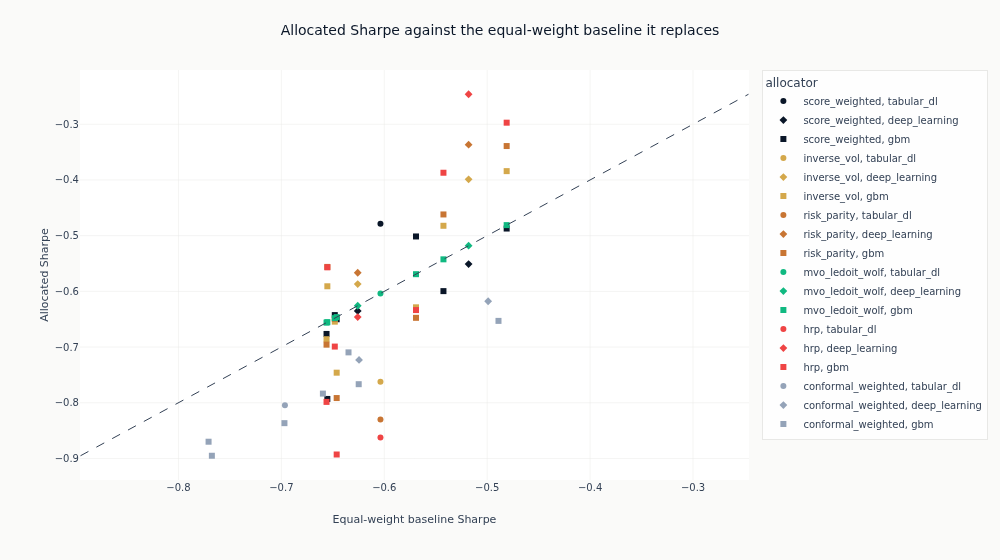

In [11]:
pairing = px.scatter(
    allocation_sharpe,
    x="baseline_sharpe",
    y="allocation_sharpe",
    color="allocation_method",
    symbol="family",
    hover_data=["baseline_hash", "backtest_hash"],
)
_axis_lo = min(
    allocation_sharpe.get_column("baseline_sharpe").min(),
    allocation_sharpe.get_column("allocation_sharpe").min(),
)
_axis_hi = max(
    allocation_sharpe.get_column("baseline_sharpe").max(),
    allocation_sharpe.get_column("allocation_sharpe").max(),
)
pairing.add_shape(
    type="line",
    x0=_axis_lo,
    y0=_axis_lo,
    x1=_axis_hi,
    y1=_axis_hi,
    line=dict(color=COLORS["neutral"], width=1, dash="dash"),
)
pairing.update_layout(
    title="Allocated Sharpe against the equal-weight baseline it replaces",
    height=560,
    width=1000,
    margin=dict(t=70),
    legend_title_text="allocator",
)
pairing.update_xaxes(title_text="Equal-weight baseline Sharpe")
pairing.update_yaxes(title_text="Allocated Sharpe")
show_plotly_with_alt(
    pairing,
    "Scatter plot of each allocation backtest's validation Sharpe against the equal-weight "
    "baseline it was built from, coloured by allocator, with the diagonal marking no change.",
)

In [12]:
pl.DataFrame(
    {
        "candidate_set": [BASELINE_CANDIDATES, STRATEGY_CANDIDATES],
        "member_count": [
            len(baseline_candidates.members) if baseline_candidates else 0,
            len(strategy_candidates.members) if strategy_candidates else 0,
        ],
        "set_hash": [
            baseline_candidates.hash if baseline_candidates else "",
            strategy_candidates.hash if strategy_candidates else "",
        ],
    }
)

candidate_set,member_count,set_hash
str,i64,str
"""sp500-options-baseline-candida…",786,"""caa48f7d7108"""
"""sp500-options-strategy-candida…",846,"""2b2083f67223"""


## Key takeaways

- A selection is only reproducible against a recorded candidate set. Freezing the set before
  ranking is what makes "the highest Sharpe" a statement someone else can check.
- Counting configurations rather than rows is what keeps a shortlist diverse; a checkpoint sweep
  of one model otherwise crowds out every other family without any rule being broken.
- Holding the signal fixed and varying only the weighting rule is what allows the difference to
  be attributed to the allocator. A comparison that also moved the concentration or the universe
  would confound the three.

**Known limitations**: the covariance-based allocators read the underlying equity's return
history, not the straddle's, so they size the hedge exposure well and the option exposure only
indirectly. Every number here is a point estimate over the validation period with no interval
attached, and the shortlist inherits whatever selection noise the baseline stage carried.